# Micro-Expression Spotting: Onset-to-Apex Window Visualization

Generates a synthetic magnitude signal and visualizes the onset frame, apex frame, and context window used by the phase spotter.

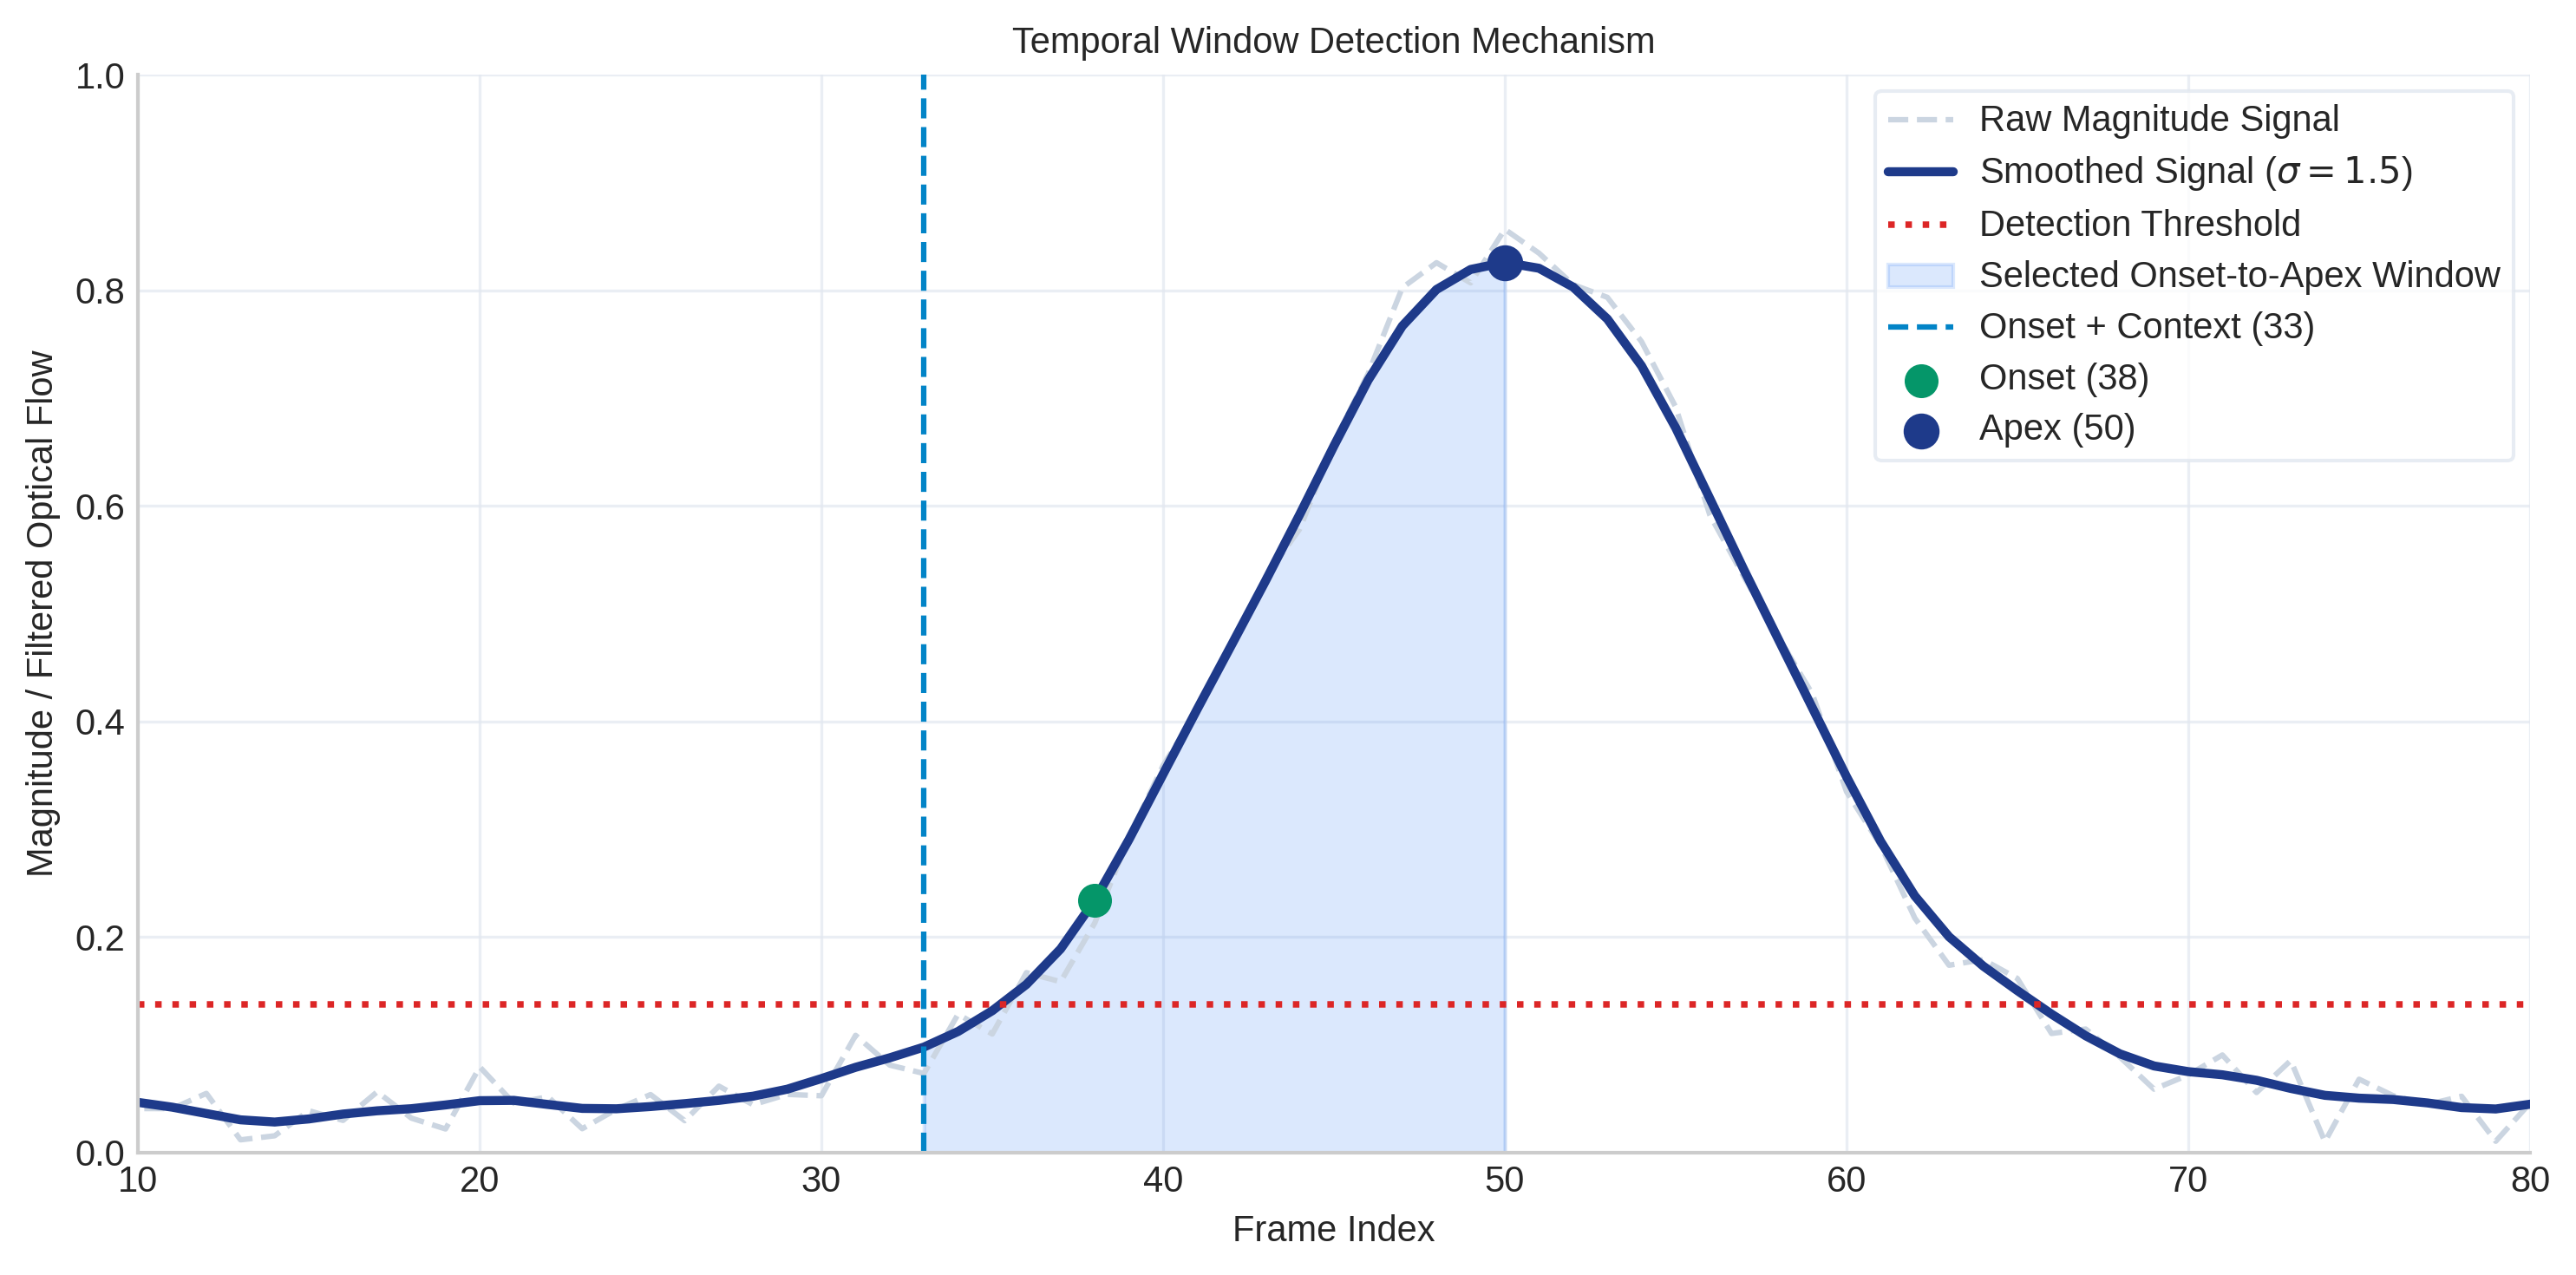

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.font_manager import FontProperties

import os

_font_path = os.path.join(os.path.dirname(__file__) if '__file__' in dir() else os.getcwd(), '../../assets/SFPRODISPLAYREGULAR.OTF')
font = FontProperties(fname=_font_path) if os.path.isfile(_font_path) else FontProperties()

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
x = np.arange(100)
peak_pos = 50

signal = 0.05 + 0.02 * np.random.randn(100)
signal += 0.8 * np.exp(-((x - peak_pos) / 10) ** 2)
signal = np.clip(signal, 0.01, None)

smoothed = gaussian_filter1d(signal, 1.5)
threshold = np.percentile(smoothed, 70)

onset = peak_pos
while onset > 1:
    if smoothed[onset] < smoothed[peak_pos] * 0.30 or smoothed[onset] < smoothed[onset - 1]:
        break
    onset -= 1

onset_context = max(0, onset - 5)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

ax.plot(x, signal, '--', color='#CBD5E1', lw=1.5, label='Raw Magnitude Signal')
ax.plot(x, smoothed, color='#1E3A8A', lw=2.5, label=r'Smoothed Signal ($\sigma=1.5$)')
ax.axhline(threshold, color='#DC2626', ls=':', lw=1.8, label='Detection Threshold')

ax.fill_between(
    x[onset_context:peak_pos + 1],
    smoothed[onset_context:peak_pos + 1],
    color='#3B82F6',
    alpha=0.18,
    label='Selected Onset-to-Apex Window'
)

ax.axvline(
    onset_context,
    color='#0284C7',
    ls='--',
    lw=1.5,
    label=f'Onset + Context ({onset_context})'
)

ax.scatter(onset, smoothed[onset], color='#059669', s=70, zorder=5, label=f'Onset ({onset})')
ax.scatter(peak_pos, smoothed[peak_pos], color='#1E3A8A', s=80, zorder=5, label=f'Apex ({peak_pos})')

ax.set(
    title='Temporal Window Detection Mechanism',
    xlabel='Frame Index',
    ylabel='Magnitude / Filtered Optical Flow',
    xlim=(10, 80),
    ylim=(0, 1)
)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#E2E8F0', lw=0.8, alpha=0.7)

legend = ax.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0',
    fontsize=9
)

for text in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
    text.set_fontproperties(font)

for text in legend.get_texts():
    text.set_fontproperties(font)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()
